# Analisis Signifikansi Fitur Kardiovaskular (Feature Importance)
Bagian ini digunakan untuk mengekstraksi metrik Feature Importance dari model Random Forest yang telah dioptimasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Data dan Model Terbaik
df = pd.read_csv('../data/heart.csv')
best_model = joblib.load('../models/best_model.pkl')

# Ekstraksi Fitur dari Pipeline
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

preprocessor = best_model.named_steps['preprocessor']
ohe_cols = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(ohe_cols)

importances = best_model.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1]

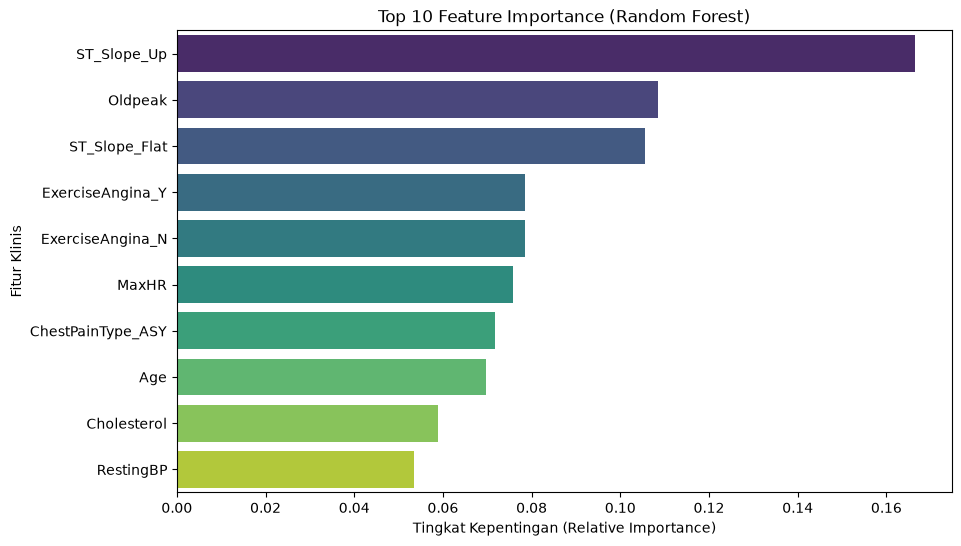

In [3]:
# Plot Grafik Bar Chart Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=[feature_names[i] for i in indices][:10], palette='viridis')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Tingkat Kepentingan (Relative Importance)')
plt.ylabel('Fitur Klinis')
plt.show()